Sliced Wasserstein Distance - Mean r-value: -0.04393703108657219
Jensen-Shannon Divergence - Mean r-value: -0.008180884833789004
Cosine Similarity between Gradients - Mean r-value: -0.045716996495629346
L2 Norm between Gradients - Mean r-value: -0.13796020123328315
Maximum Mean Discrepancy - Mean r-value: -0.19129000377409408
Hellinger Distance - Mean r-value: -0.026554195392524016
Frechet-Inception Distance - Mean r-value: 0.06984008358418872


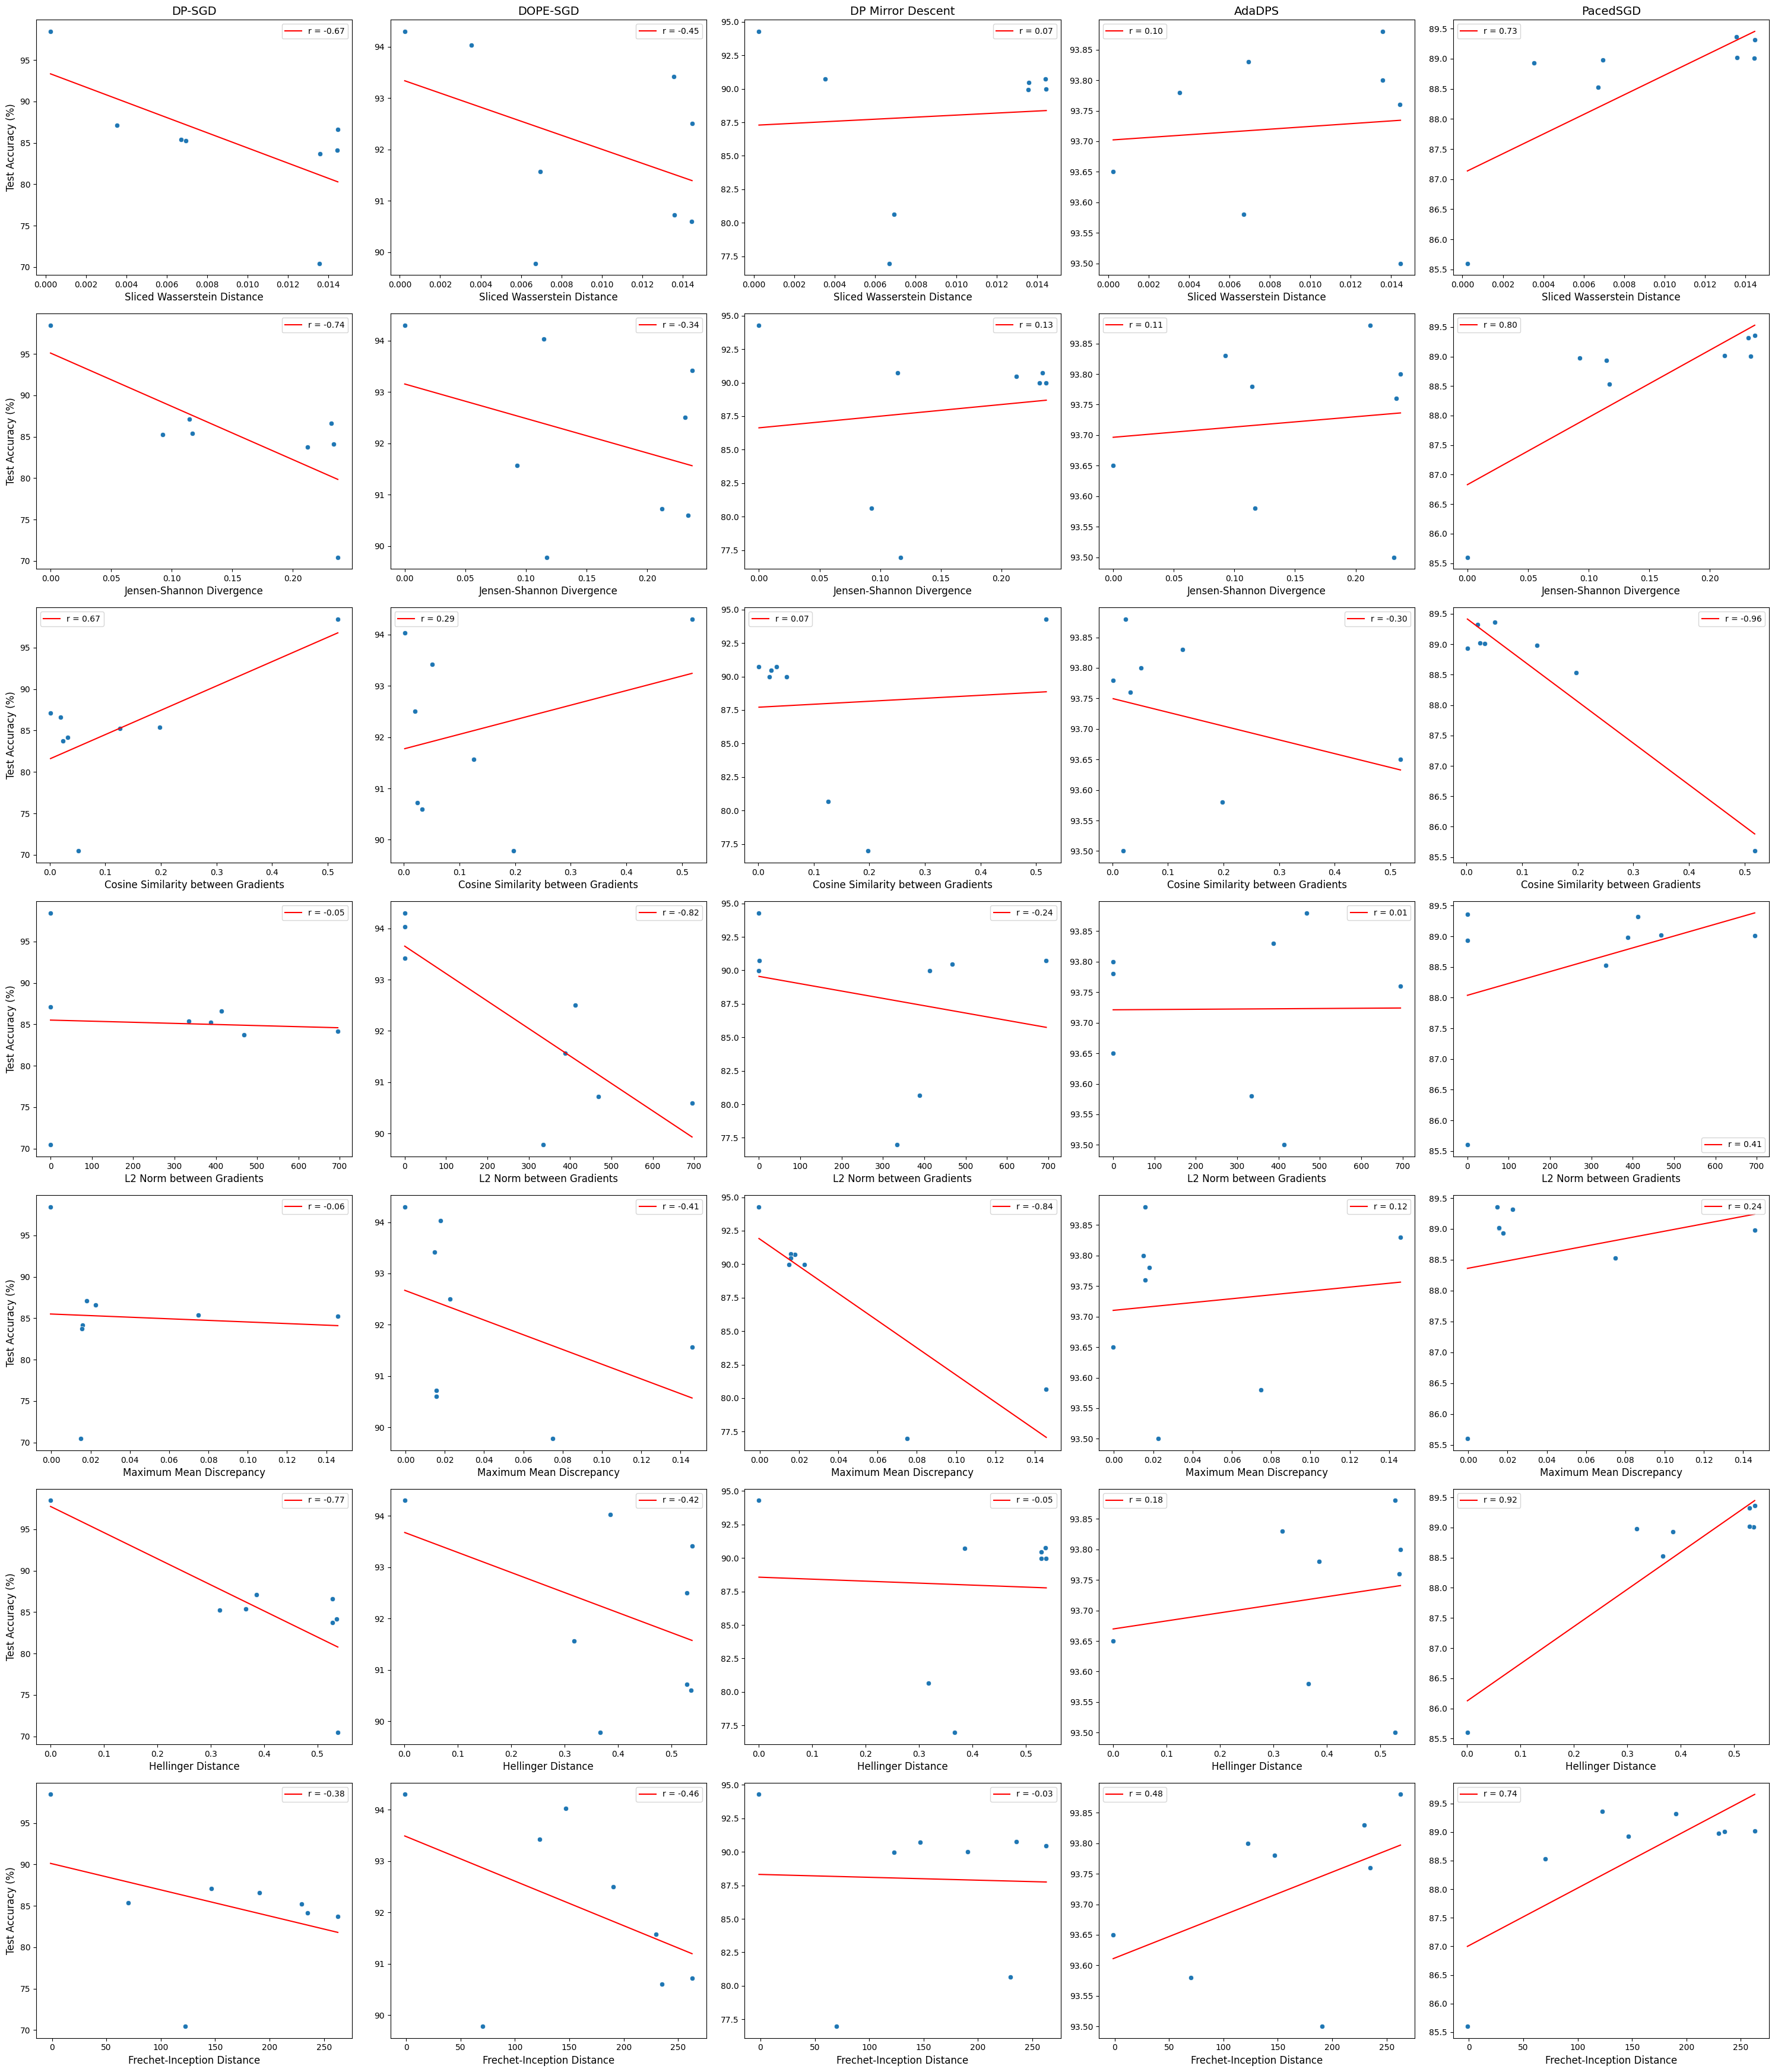

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress


order = ["USPS", "FashionMNIST", "SVHN", "CIFAR-10", "STL-10", "QMNIST", "KMNIST", "SEMEION"]


s_was_sim = [0.003530991563, 0.006940077492, 0.014461491775, 0.014432070567, 0.01358911509, 0.000248053066, 0.006706206547, 0.013562417714]
jsd_sim = [0.114499000000, 0.092713000000, 0.231467000000, 0.233652000000, 0.212181, 0.000000170178, 0.117018167721, 0.236999708724]
cosine_sim = [0.0015, 0.1261, 0.0197, 0.0326, 0.0238, 0.518260598183, 0.197512239218, 0.051266677678]
l2_norm_sim = [0.074, 388.1557, 413.0328, 695.0426, 468.1418, 0.000925271768, 334.347686767578, 0.001943506637]
mmd_sim = [0.017933581, 0.14585292, 0.022628454, 0.015758608, 0.01574812, -0.000386925530, 0.074872170000, 0.014904100000]
hellinger_sim = [0.385654985772, 0.317277278800, 0.528687696487, 0.536272981830, 0.528780144, 0.000443533919, 0.366413510639, 0.538365693953]
fid_sim = [146.760162353515, 229.598815917968, 190.478591918945, 235.153808593750, 262.777221679687, -1.3309631347625, 70.104888916016, 122.696960000000]
our_sim = [0.2707, 0.3825, 0.4167, 0.3947, 0.2475, 0.9727, 0.3510, 0.0007]
crazy_sim = [18.388149975473, 5.688674026957, 9.806939638491, 7.163322011771, 4.580205978194, 1.814514357265, 7.384720720562, 2.075283477288]
"""encoder_256 = [
0.1812,
0.3040,
0.3516,
0.2970,
0.1352,
0.3259,
0.2705,
0.0003,
0.3266]
encoder_512 = [
0.0854,
0.2842,
0.3286,
0.2822,
0.0599,
0.1006,
0.2397,
8.6256e-05,
0.1008]
encoder_56 = [
    0.3926, 
    0.4419,
    0.4655,
    0.4521,
    0.3593,
    0.9889,
    0.4442,
    0.0018,
    1.0000
]
encoder_32 = [
    0.4269,
    0.4510,
    0.4787,
    0.4777,
    0.4072,
    0.9935,
    0.4699,
    0.0037,
    1
]
encoder_128 = [
    0.2779, 0.3572, 0.4182, 0.3710, 0.2297, 0.9726, 0.3436, 0.0007, 1.0000
]
resnet_layer3 = [0.4413, 0.4981, 0.4990, 0.4983, 0.4591, 0.4944, 0.4986, 0.0656, 0.4944]
resnet_layer1 = [0.3561, 0.4922, 0.4932, 0.4922, 0.4575, 0.2683, 0.4924, 0.0065, 0.4575]"""

basic_dp_sgd = [87.10, 85.25, 86.60, 84.14, 83.72, 98.46, 85.37, 70.45]
basic_dope_sgd = [94.03, 91.57, 92.5, 90.60, 90.72, 94.30, 89.78, 93.42]
basic_mirror_descent = [90.74, 80.65, 89.99, 90.75, 90.47, 94.29, 76.97, 89.96]
basic_ada_dps = [93.78, 93.83, 93.50, 93.76, 93.88, 93.65, 93.58, 93.80]
paced = [88.93,
88.98,
89.32,
89.01,
89.02,
85.60,
88.53,
89.36]


all_algorithms = {
   "DP-SGD": basic_dp_sgd,
   "DOPE-SGD": basic_dope_sgd,
   "DP Mirror Descent": basic_mirror_descent,
   "AdaDPS": basic_ada_dps,
   "PacedSGD": paced
}


all_similarity_metrics = {
   "Sliced Wasserstein Distance": s_was_sim,
   "Jensen-Shannon Divergence": jsd_sim,
   "Cosine Similarity between Gradients": cosine_sim,
   "L2 Norm between Gradients": l2_norm_sim,
   "Maximum Mean Discrepancy": mmd_sim,
   "Hellinger Distance": hellinger_sim,
   "Frechet-Inception Distance": fid_sim,
   #"Encoder_256":encoder_256,
   #"Encoder_512":encoder_512,
   #"Resnet 3_layer":resnet_layer3,
   #"Resnet 1_layer": resnet_layer1,
   #"Encoder_56": encoder_56,
   #"Encoder_32": encoder_32,
   #"Encoder_128": encoder_128,
   #"Our Similarity Metric": our_sim,
   #"Crazy Similarity": crazy_sim

}


k = len(all_algorithms)
n = len(all_similarity_metrics)
fig, axes = plt.subplots(nrows=n, ncols=k, figsize=(6 * k, 5 * n), squeeze=False)


for row_idx, (sim_name, sim_values) in enumerate(all_similarity_metrics.items()):
   total_r = 0
   for col_idx, (algo_name, accuracies) in enumerate(all_algorithms.items()):
      
       ax = axes[row_idx][col_idx]


       # Scatter plot
       sns.scatterplot(x=sim_values, y=accuracies, ax=ax)


       # Fit line
       slope, intercept, r_value, _, _ = linregress(sim_values, accuracies)
       total_r += r_value
       x_vals = sorted(sim_values)
       y_vals = [slope * x + intercept for x in x_vals]
       ax.plot(x_vals, y_vals, color='red', label=f'r = {r_value:.2f}')


       # Labeling
       if row_idx == 0:
           ax.set_title(f"{algo_name}", fontsize=14)
       if col_idx == 0:
           ax.set_ylabel("Test Accuracy (%)", fontsize=12)
       else:
           ax.set_ylabel("")
       ax.set_xlabel(f"{sim_name}", fontsize=12)
       ax.legend()
   print(f"{sim_name} - Mean r-value: {total_r/k}")


plt.tight_layout()
plt.show()